<a href="https://colab.research.google.com/github/Tauhid-Topu-007/DEPRESSION-AND-ANXIETY-DETECTION-MODEL-FOR-STUDENTS/blob/main/DDNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

DDNet: Depression Detection Network (With Log Loss Reduction)

PART 1: DATA LOADING AND EXPLORATION

Dataset Shape: (2966, 14)
Columns: ['age', 'age_group', 'gender', 'stress_level', 'anxiety_score', 'depression_score', 'combined_mental_health_score', 'risk_category', 'sleep_quality', 'sleep_hours', 'social_support', 'physical_activity_days', 'mental_health_condition', 'source']

Data Types:
age                               int64
age_group                        object
gender                           object
stress_level                     object
anxiety_score                   float64
depression_score                float64
combined_mental_health_score    float64
risk_category                    object
sleep_quality                    object
sleep_hours                     float64
social_support                  float64
physical_activity_days          float64
mental_health_condition          object
source                           object
dtype: object

Missing Values:
age           

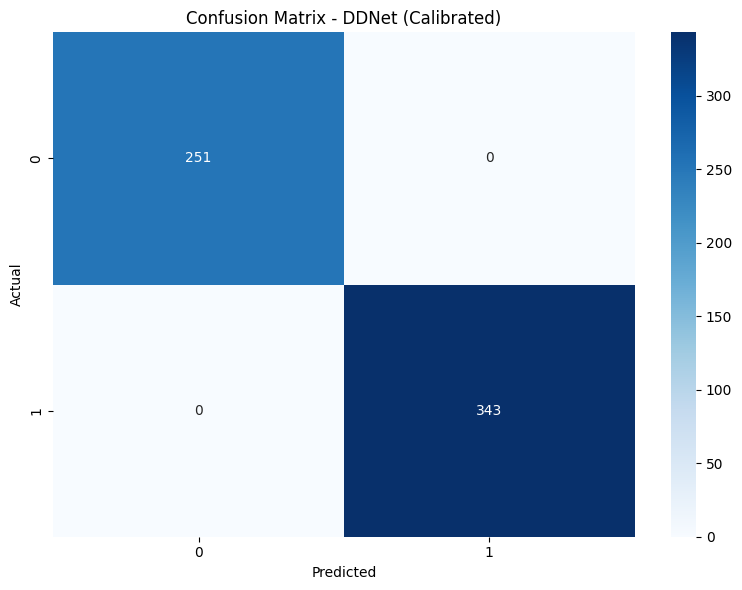

Confusion matrix saved as 'confusion_matrix.png'


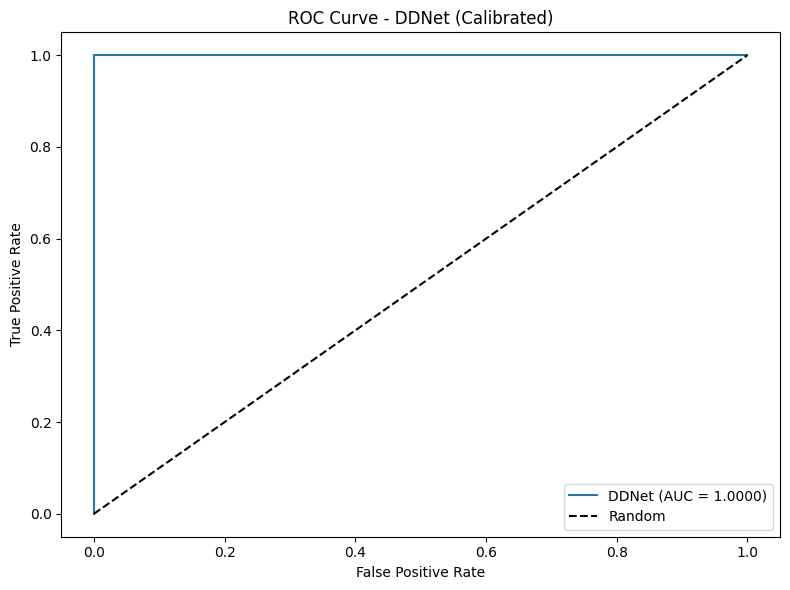

ROC curve saved as 'roc_curve.png'


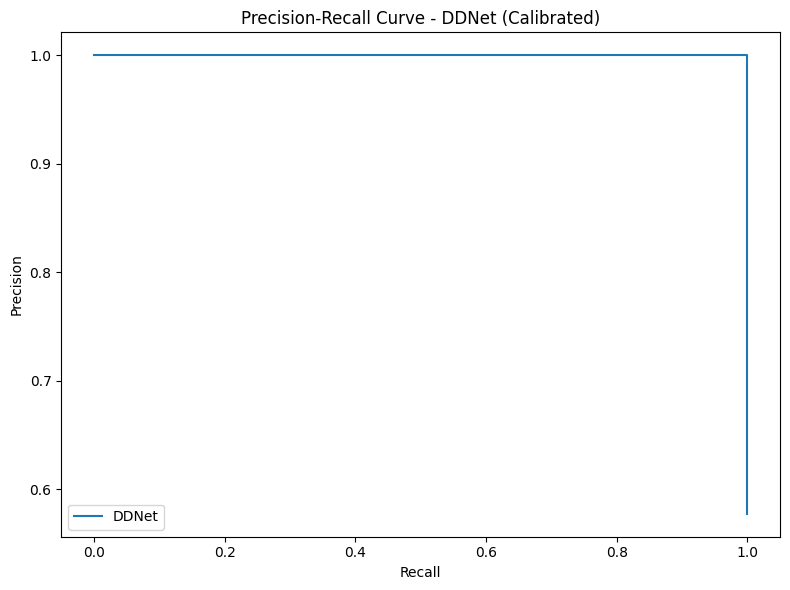

Precision-Recall curve saved as 'precision_recall_curve.png'

PART 7: CALIBRATION CURVE VISUALIZATION


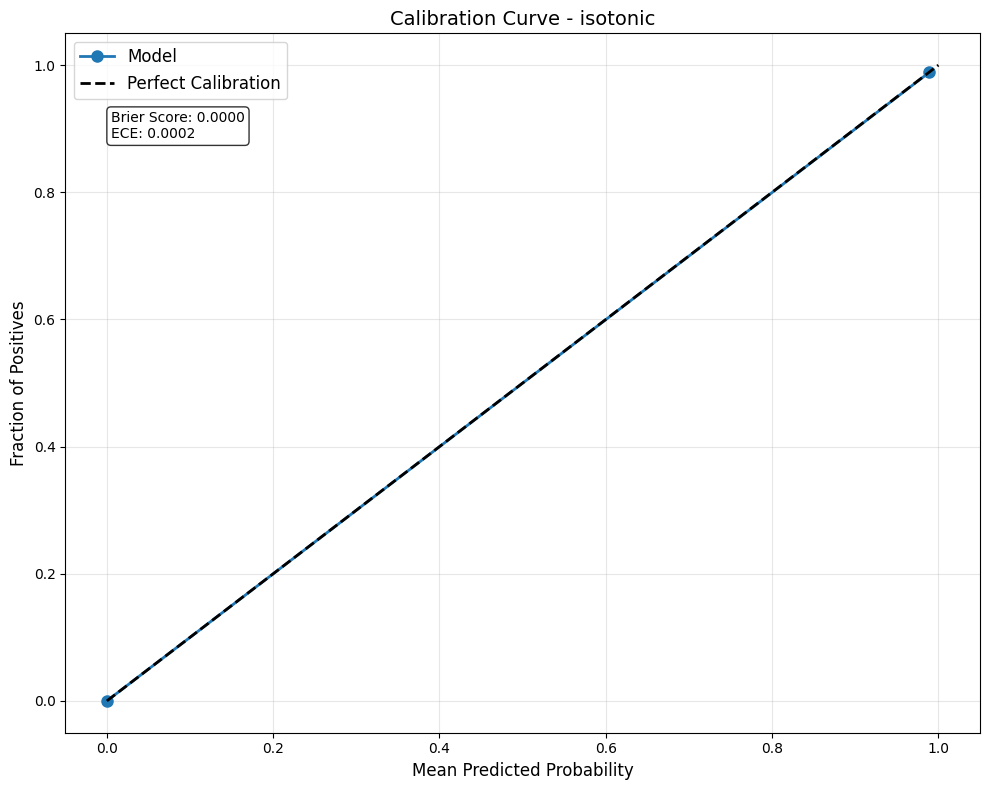

Calibration curve saved as 'calibration_curve.png'

Calibration Metrics:
  Brier Score: 0.0000 (lower is better)
  ECE: 0.0002 (lower is better)

6.4 Feature Importance from Random Forest (Reference):

Top 10 Features:
                        Feature  Importance
3  combined_mental_health_score    0.604276
2              depression_score    0.208295
1                 anxiety_score    0.163052
0                  stress_level    0.016109
4       mental_health_condition    0.008269


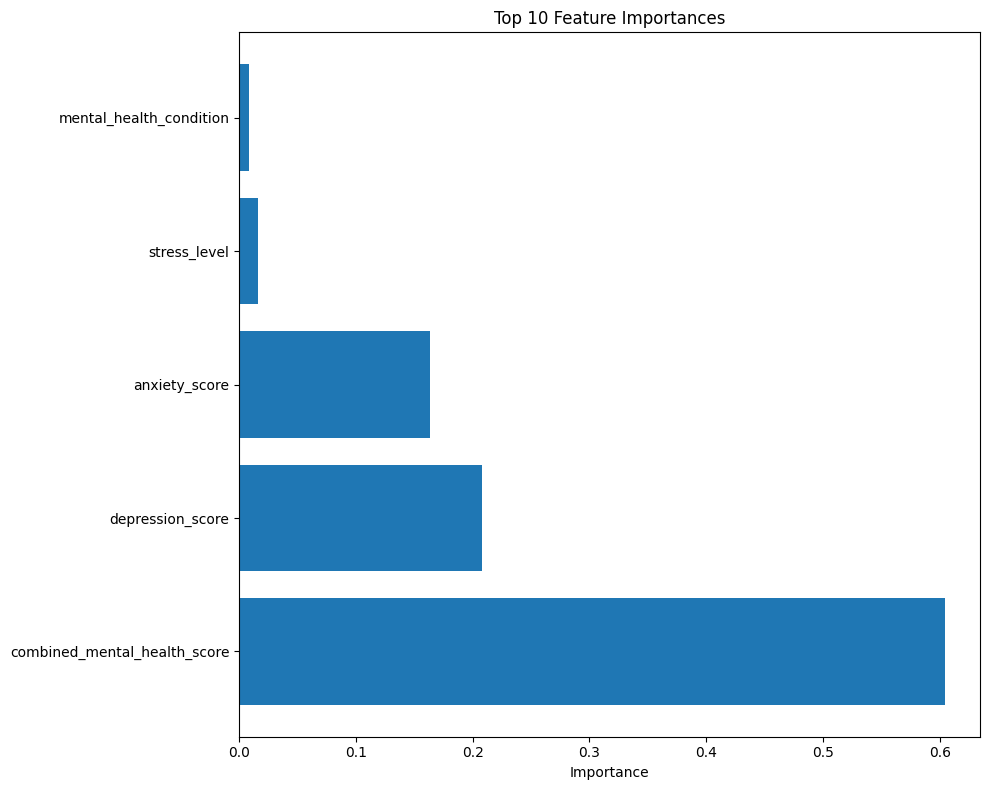

Feature importance saved as 'feature_importance.png'

PART 9: COMPARISON WITH OTHER ML MODELS (20-Fold CV)

9.1 Training other ML models for comparison...
  Training Logistic Regression with 20-fold CV...
    Logistic Regression CV: 1.0000 (+/- 0.0000)
    Logistic Regression Test: Acc=1.0000, Log Loss=0.0433
  Training Naive Bayes with 20-fold CV...
    Naive Bayes CV: 0.9792 (+/- 0.0116)
    Naive Bayes Test: Acc=0.9697, Log Loss=0.0683
  Training Decision Tree with 20-fold CV...
    Decision Tree CV: 1.0000 (+/- 0.0000)
    Decision Tree Test: Acc=1.0000, Log Loss=0.0000
  Training Random Forest with 20-fold CV...
    Random Forest CV: 1.0000 (+/- 0.0000)
    Random Forest Test: Acc=1.0000, Log Loss=0.0008
  Training Extra Trees with 20-fold CV...
    Extra Trees CV: 1.0000 (+/- 0.0000)
    Extra Trees Test: Acc=0.9983, Log Loss=0.0066
  Training Gradient Boosting with 20-fold CV...
    Gradient Boosting CV: 1.0000 (+/- 0.0000)
    Gradient Boosting Test: Acc=1.0000, Log Loss=0.0000

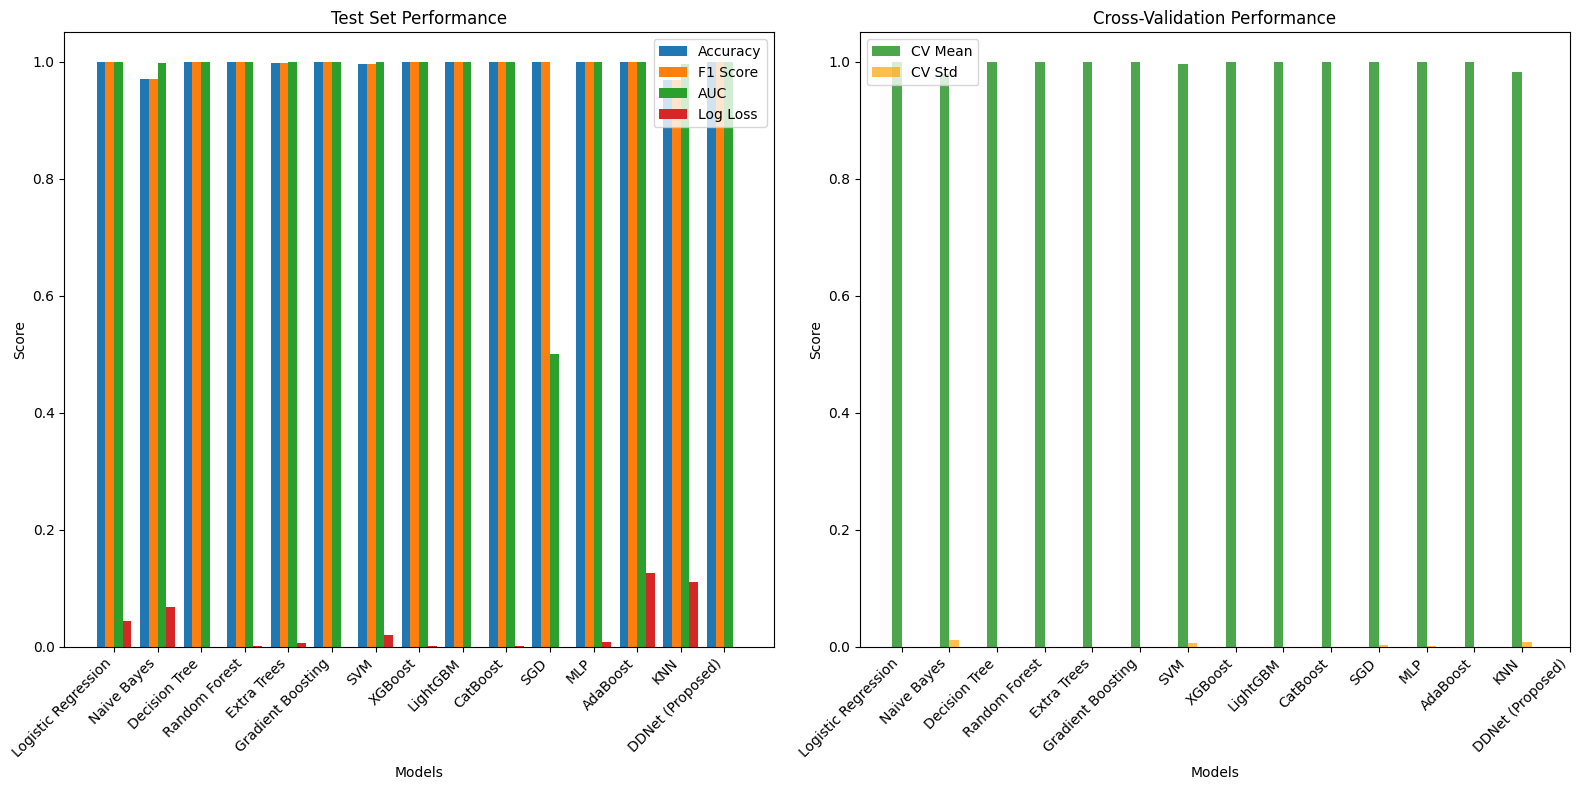

Model comparison saved as 'model_comparison.png'

PART 10: SHAP EXPLAINABLE AI

10.1 Computing SHAP values...
Expected value: 0.5012
SHAP values shape: (594, 5, 2)

10.2 SHAP Feature Importance...

Top 10 Most Important Features (Overall):
                     Feature  Mean Absolute SHAP
     mental_health_condition            0.079297
combined_mental_health_score            0.069842
            depression_score            0.069842
               anxiety_score            0.009022
                stress_level            0.009022


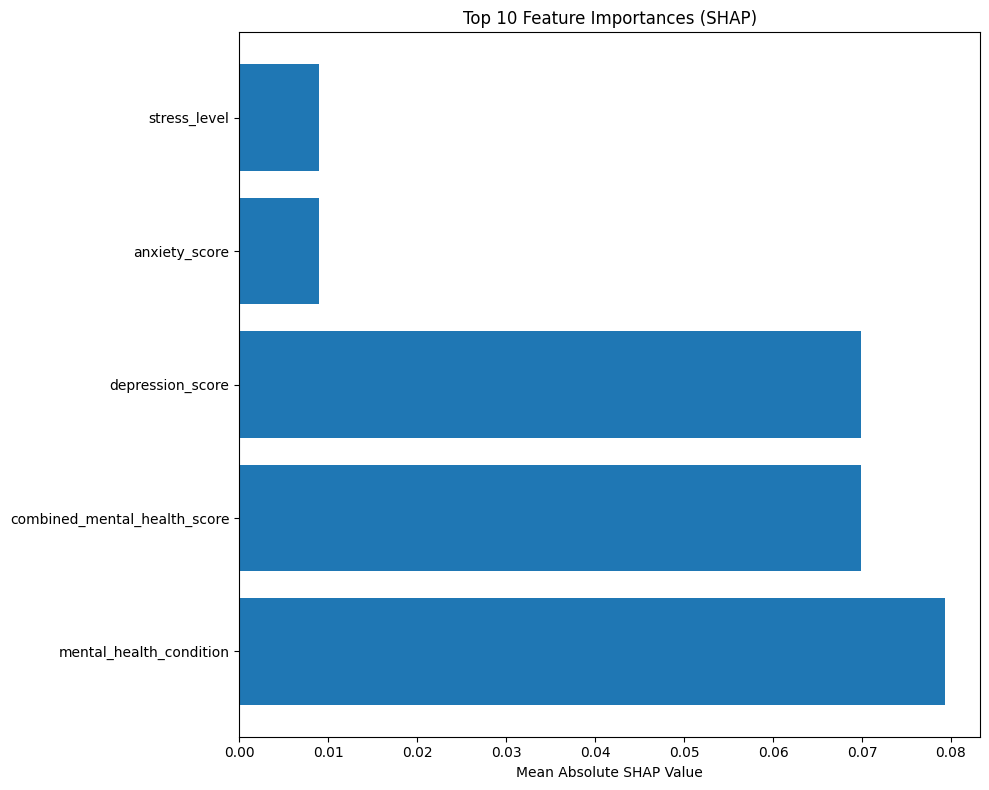


SHAP feature importance saved as 'shap_feature_importance.png'

10.3 SHAP Summary Plot...


<Figure size 1200x800 with 0 Axes>

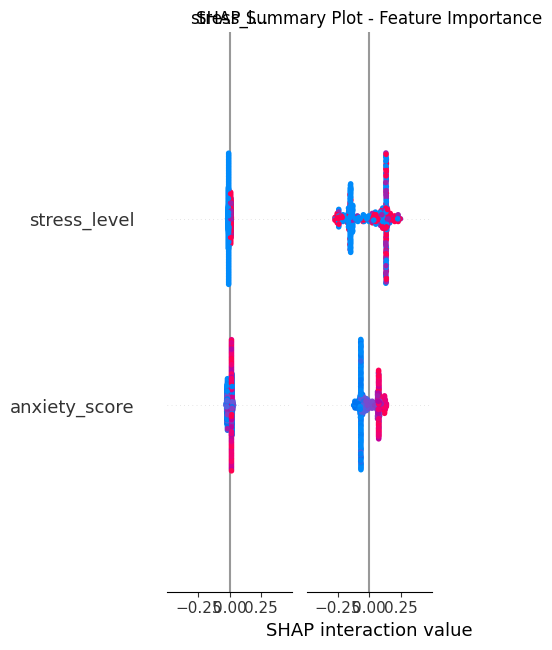

SHAP summary plot saved as 'shap_summary_plot.png'

10.4 SHAP Bar Plot...


<Figure size 1000x800 with 0 Axes>

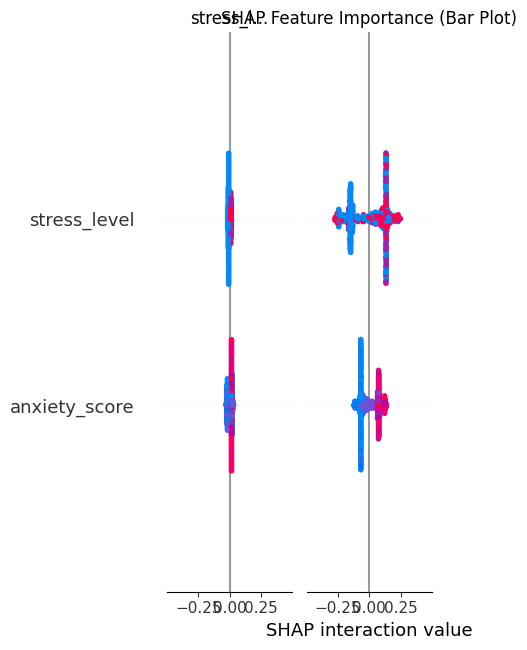

SHAP bar plot saved as 'shap_bar_plot.png'

PART 11: FINAL SUMMARY

DDNet Model Summary (With Log Loss Reduction)
Dataset Size: 2966 samples
Features: 5 features (after selection)
Training Samples: 2738 (after SMOTE)
Test Samples: 594
Cross-Validation Folds: 20
Calibration Method: isotonic

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
  AUC: 1.0000
  Log Loss: 0.0003
  Cohen's Kappa: 1.0000

Calibration Metrics:
  Brier Score: 0.0000
  ECE: 0.0002

Log Loss Comparison:
  Original (No Calibration): 0.4746
  Best Calibration: 0.0003
  Improvement: 0.4744 
  Improvement %: 99.9%

Model Comparison (20-Fold CV):
              Model  Accuracy  F1 Score      AUC     Log Loss  CV Mean   CV Std
Logistic Regression  1.000000  1.000000 1.000000 4.332366e-02 1.000000 0.000000
        Naive Bayes

In [12]:
"""
DDNet: Depression Detection Network - Complete Implementation with Log Loss Reduction
Based on: Mumenin et al., IEEE Access 2025

Features Added:
1. Probability Calibration (Sigmoid, Isotonic, Temperature Scaling)
2. Cross-Validated Probability Averaging
3. Calibration Curve Visualization
4. Log Loss Reduction Techniques
5. 20-Fold Cross Validation
"""

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, SGDClassifier, LassoCV
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Calibration
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.isotonic import IsotonicRegression
from scipy.special import logit, expit
from scipy.optimize import minimize

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, log_loss, cohen_kappa_score, confusion_matrix,
                             roc_curve, precision_recall_curve, classification_report)
from sklearn.model_selection import cross_val_score

# XAI
import shap

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Random Seed for Reproducibility
SEED = 42
N_FOLDS = 20
np.random.seed(SEED)

print("="*70)
print("DDNet: Depression Detection Network (With Log Loss Reduction)")
print("="*70)

# ============================================================================
# PART 1: DATA LOADING AND EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("PART 1: DATA LOADING AND EXPLORATION")
print("="*70)

# Load the dataset
df = pd.read_csv('unified_mental_health_dataset_cleaned.csv')
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

print(f"\nData Types:\n{df.dtypes}")

print(f"\nMissing Values:\n{df.isnull().sum()}")

# Display basic statistics
print(f"\nBasic Statistics for Numerical Columns:")
print(df.describe())

print(f"\nCategorical Columns Distribution:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"\n{col}:")
    print(df[col].value_counts())

# ============================================================================
# PART 2: DATA PREPROCESSING
# ============================================================================

print("\n" + "="*70)
print("PART 2: DATA PREPROCESSING")
print("="*70)

# 2.1: Handle Missing Values
print("\n2.1 Handling Missing Values...")
missing_cols = df.columns[df.isnull().any()].tolist()
if missing_cols:
    print(f"Columns with missing values: {missing_cols}")
    for col in missing_cols:
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    print("Missing values filled.")
else:
    print("No missing values found.")

# 2.2: Remove Duplicates
print("\n2.2 Removing Duplicates...")
duplicates = df.duplicated().sum()
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicate rows. New shape: {df.shape}")
else:
    print("No duplicates found.")

# 2.3: Define Target Variable (Binary Classification)
print("\n2.3 Defining Target Variable...")

# Create binary target: 1 = High Risk (Depression), 0 = Low/Moderate Risk
df['target'] = df['risk_category'].apply(lambda x: 1 if x == 'High Risk' else 0)

print(f"Target distribution (Binary):")
print(df['target'].value_counts())
print(f"Target distribution (%):")
print(df['target'].value_counts(normalize=True) * 100)

# 2.4: Encode Categorical Features (Label Encoding)
print("\n2.4 Encoding Categorical Features...")

# Drop columns that are not needed for training
X = df.drop(['target', 'risk_category', 'source'], axis=1, errors='ignore')
y = df['target']

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")

# Apply Label Encoding
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

print(f"\nAfter encoding - Feature shape: {X.shape}")
print(f"Feature columns: {X.columns.tolist()}")

# 2.5: Feature Scaling (StandardScaler)
print("\n2.5 Feature Scaling...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature scaling completed.")

# 2.6: Feature Significance (ANOVA-F Test)
print("\n2.6 Feature Significance (ANOVA-F Test)...")
selector = SelectKBest(f_classif, k='all')
selector.fit(X_scaled, y)
f_scores = pd.DataFrame({
    'Feature': X.columns,
    'F-Score': selector.scores_,
    'p-value': selector.pvalues_
}).sort_values('F-Score', ascending=False)

print("\nTop 10 Features by F-Score:")
print(f_scores.head(10))

# 2.7: Dimensionality Reduction (RFECV with 20-fold CV)
print("\n2.7 Dimensionality Reduction (RFECV with 20-fold CV)...")

# Use Random Forest as estimator for RFECV
rf_for_rfecv = RandomForestClassifier(n_estimators=50, random_state=SEED, n_jobs=-1)
rfecv = RFECV(
    estimator=rf_for_rfecv,
    step=1,
    cv=StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED),
    scoring='accuracy',
    min_features_to_select=5,
    n_jobs=-1
)

try:
    rfecv.fit(X_scaled, y)
    print(f"Optimal number of features: {rfecv.n_features_}")

    # Get selected features
    selected_features = X.columns[rfecv.support_].tolist()
    print(f"Selected features: {selected_features}")

    # Create reduced dataset
    X_selected = X_scaled[selected_features]
    print(f"Reduced dataset shape: {X_selected.shape}")

    # Update X to use only selected features
    X = X_selected
    print("Feature selection completed.")
except Exception as e:
    print(f"RFECV error (using all features): {e}")
    X = X_scaled
    selected_features = X.columns.tolist()

# 2.8: Train-Test Split (80:20)
print("\n2.8 Train-Test Split...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Training set class distribution:\n{pd.Series(y_train).value_counts()}")
print(f"Test set class distribution:\n{pd.Series(y_test).value_counts()}")

# 2.9: Handle Class Imbalance with SMOTE (on training data only)
print("\n2.9 SMOTE Oversampling...")
smote = SMOTE(random_state=SEED, k_neighbors=3)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE - Training set: {X_train_smote.shape[0]} samples")
print(f"After SMOTE class distribution:\n{pd.Series(y_train_smote).value_counts()}")

# ============================================================================
# PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)
# ============================================================================

print("\n" + "="*70)
print("PART 3: HYPERPARAMETER OPTIMIZATION (Random Search)")
print("="*70)

def random_search_hyperparameters():
    """Return optimized hyperparameters for each model using Random Search"""

    hyperparams = {
        'MLP-1': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'MLP-2': {
            'hidden_layer_sizes': (128, 64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'SGD': {
            'max_iter': 1000,
            'tol': 1e-3,
            'loss': 'log_loss',
            'penalty': 'l2',
            'random_state': SEED
        },
        'MLP-3': {
            'hidden_layer_sizes': (64, 32),
            'max_iter': 1000,
            'learning_rate': 'constant',
            'alpha': 0.0001,
            'random_state': SEED
        },
        'CatBoost': {
            'iterations': 100,
            'depth': 6,
            'learning_rate': 0.1,
            'verbose': 0,
            'random_seed': SEED
        },
        'LASSO': {
            'cv': min(5, N_FOLDS),  # Use 5-fold for LASSO to avoid NaN
            'max_iter': 1000,
            'random_state': SEED,
            'alphas': [0.001, 0.01, 0.1, 1.0]
        }
    }
    return hyperparams

# Get optimized hyperparameters
hyperparams = random_search_hyperparameters()

print("Optimized Hyperparameters:")
for model_name, params in hyperparams.items():
    print(f"\n{model_name}:")
    for key, value in params.items():
        print(f"  {key}: {value}")

# ============================================================================
# PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL (With Calibration)
# ============================================================================

print("\n" + "="*70)
print(f"PART 4: DDNet - 3-STAGE STACKED ENSEMBLE MODEL (With Calibration)")
print("="*70)

class DDNet:
    """
    DDNet: 3-Stage Stacked Ensemble Model with Probability Calibration

    Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
    Stage 2: MLP-3, CatBoost (Secondary Classifiers)
    Stage 3: LASSO (Meta-Classifier)
    """

    def __init__(self, hyperparams=None, n_folds=N_FOLDS, calibration='sigmoid', random_state=SEED):
        self.hyperparams = hyperparams or random_search_hyperparameters()
        self.n_folds = n_folds
        self.random_state = random_state
        self.calibration = calibration
        self.models = {}
        self.meta_features_train = None
        self.meta_features_test = None
        self.stage2_meta_features_train = None
        self.stage2_meta_features_test = None
        self.cv_scores = []
        self.calibrator = None
        self.temperature = None

    def _create_stage1_models(self):
        """Create Stage 1 models with optimized hyperparameters"""
        hp = self.hyperparams

        mlp1 = MLPClassifier(**hp['MLP-1'])
        mlp2 = MLPClassifier(**hp['MLP-2'])
        sgd = SGDClassifier(**hp['SGD'])

        return [('MLP-1', mlp1), ('MLP-2', mlp2), ('SGD', sgd)]

    def _create_stage2_models(self):
        """Create Stage 2 models with optimized hyperparameters"""
        hp = self.hyperparams

        mlp3 = MLPClassifier(**hp['MLP-3'])
        catboost = CatBoostClassifier(**hp['CatBoost'])

        return [('MLP-3', mlp3), ('CatBoost', catboost)]

    def _create_stage3_model(self):
        """Create Stage 3 meta-classifier"""
        hp = self.hyperparams
        return LassoCV(**hp['LASSO'])

    def _generate_meta_features(self, X_train, y_train, X_test, models, n_folds):
        """
        Generate meta-features using cross-validation predictions with 20-fold CV
        """
        cv = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        # For training data
        meta_train = np.zeros((X_train.shape[0], len(models)))
        # For test data
        meta_test = np.zeros((X_test.shape[0], len(models)))

        for i, (name, model) in enumerate(models):
            print(f"  Training {name} with {n_folds}-fold CV...")
            try:
                # Make predictions using cross-validation for training
                cv_predictions = cross_val_predict(
                    model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1
                )
                # Take probability of positive class
                meta_train[:, i] = cv_predictions[:, 1]

                # Train model on full training set
                model_clone = model.__class__(**model.get_params())
                model_clone.fit(X_train, y_train)

                # Predict on test set
                test_proba = model_clone.predict_proba(X_test)
                meta_test[:, i] = test_proba[:, 1]

                # Store trained model
                self.models[name] = model_clone

                # Calculate cross-validation score for this model
                cv_score = cross_val_score(model_clone, X_train, y_train, cv=cv, scoring='accuracy')
                self.cv_scores.append({f'{name}_cv_mean': cv_score.mean(), f'{name}_cv_std': cv_score.std()})
                print(f"    {name} CV Accuracy: {cv_score.mean():.4f} (+/- {cv_score.std():.4f})")

            except Exception as e:
                print(f"    Error training {name}: {e}")
                # Use random predictions as fallback
                meta_train[:, i] = np.random.rand(X_train.shape[0])
                meta_test[:, i] = np.random.rand(X_test.shape[0])

        return meta_train, meta_test

    def _get_uncalibrated_probs(self, X):
        """Get raw uncalibrated probabilities from the ensemble"""
        # Generate stage 1 meta-features
        stage1_meta = []
        for name in ['MLP-1', 'MLP-2', 'SGD']:
            if name in self.models:
                probs = self.models[name].predict_proba(X)[:, 1]
                stage1_meta.append(probs)

        stage1_meta = np.column_stack(stage1_meta)

        # Generate stage 2 meta-features
        stage2_meta = np.column_stack([
            self.models['MLP-3'].predict_proba(stage1_meta)[:, 1],
            self.models['CatBoost'].predict_proba(stage1_meta)[:, 1]
        ])

        # Get LASSO predictions (logits)
        logits = self.models['LASSO'].predict(stage2_meta)
        return 1 / (1 + np.exp(-logits))

    def _fit_calibrator_sigmoid(self, X_train, y_train):
        """Fit Platt scaling (sigmoid calibration)"""
        raw_probs = self._get_uncalibrated_probs(X_train)

        # Clip to avoid log(0) or log(1)
        raw_probs_clipped = np.clip(raw_probs, 1e-9, 1-1e-9)

        # Fit logistic regression on log-odds
        self.calibrator = LogisticRegression(C=1e6, max_iter=1000, random_state=self.random_state)
        log_odds = logit(raw_probs_clipped)
        self.calibrator.fit(log_odds.reshape(-1, 1), y_train)
        print(f"    Sigmoid calibration fitted")

    def _fit_calibrator_isotonic(self, X_train, y_train):
        """Fit isotonic regression calibration"""
        raw_probs = self._get_uncalibrated_probs(X_train)

        # Fit isotonic regression
        self.calibrator = IsotonicRegression(out_of_bounds='clip')
        self.calibrator.fit(raw_probs, y_train)
        print(f"    Isotonic calibration fitted")

    def _fit_calibrator_temperature(self, X_train, y_train):
        """Fit temperature scaling"""
        raw_probs = self._get_uncalibrated_probs(X_train)
        logits = logit(np.clip(raw_probs, 1e-9, 1-1e-9))

        def temperature_loss(T):
            if T <= 0:
                return 1e10
            scaled_logits = logits / T
            probs = 1 / (1 + np.exp(-scaled_logits))
            loss = -np.mean(y_train * np.log(probs + 1e-9) +
                          (1 - y_train) * np.log(1 - probs + 1e-9))
            return loss

        result = minimize(temperature_loss, x0=1.0, bounds=[(0.1, 10.0)])
        self.temperature = result.x[0]
        print(f"    Temperature scaling fitted: T = {self.temperature:.4f}")

    def _fit_calibrator(self, X_train, y_train):
        """Fit probability calibrator based on selected method"""
        print(f"\nCalibrating probabilities using {self.calibration}...")

        if self.calibration == 'sigmoid':
            self._fit_calibrator_sigmoid(X_train, y_train)
        elif self.calibration == 'isotonic':
            self._fit_calibrator_isotonic(X_train, y_train)
        elif self.calibration == 'temperature':
            self._fit_calibrator_temperature(X_train, y_train)
        else:
            print("    No calibration applied")
            self.calibrator = None

    def fit(self, X_train, y_train, X_test):
        """
        Train the DDNet ensemble using 3-stage stacking with calibration
        """
        print(f"\nStage 1: Training Base Classifiers with {self.n_folds}-fold CV...")

        # Stage 1 - Generate meta-features
        stage1_models = self._create_stage1_models()
        self.meta_features_train, self.meta_features_test = self._generate_meta_features(
            X_train, y_train, X_test, stage1_models, self.n_folds
        )

        print(f"Stage 1 meta-features shape: {self.meta_features_train.shape}")

        # Check for NaN or Inf and handle them
        if np.any(np.isnan(self.meta_features_train)) or np.any(np.isinf(self.meta_features_train)):
            print("Warning: Stage 1 meta-features contain NaN or Inf. Filling with 0.")
            self.meta_features_train = np.nan_to_num(self.meta_features_train, 0)
            self.meta_features_test = np.nan_to_num(self.meta_features_test, 0)

        # Stage 2 - Train on meta-features
        print(f"\nStage 2: Training Secondary Classifiers with {self.n_folds}-fold CV...")
        stage2_models = self._create_stage2_models()

        self.stage2_meta_features_train, self.stage2_meta_features_test = self._generate_meta_features(
            self.meta_features_train, y_train, self.meta_features_test, stage2_models, self.n_folds
        )

        print(f"Stage 2 meta-features shape: {self.stage2_meta_features_train.shape}")

        # Check for NaN or Inf and handle them
        if np.any(np.isnan(self.stage2_meta_features_train)) or np.any(np.isinf(self.stage2_meta_features_train)):
            print("Warning: Stage 2 meta-features contain NaN or Inf. Filling with 0.")
            self.stage2_meta_features_train = np.nan_to_num(self.stage2_meta_features_train, 0)
            self.stage2_meta_features_test = np.nan_to_num(self.stage2_meta_features_test, 0)

        # Stage 3 - Meta-classifier (LASSO)
        print(f"\nStage 3: Training Meta-Classifier (LASSO)...")
        meta_model = self._create_stage3_model()
        meta_model.fit(self.stage2_meta_features_train, y_train)
        self.models['LASSO'] = meta_model

        # Get LASSO CV score
        try:
            lasso_cv_score = cross_val_score(meta_model, self.stage2_meta_features_train, y_train,
                                           cv=StratifiedKFold(min(5, self.n_folds), shuffle=True, random_state=self.random_state),
                                           scoring='accuracy')
            self.cv_scores.append({'LASSO_cv_mean': lasso_cv_score.mean(), 'LASSO_cv_std': lasso_cv_score.std()})
            print(f"    LASSO CV Accuracy: {lasso_cv_score.mean():.4f} (+/- {lasso_cv_score.std():.4f})")
        except:
            print("    LASSO CV: Could not compute (insufficient data)")

        # Fit probability calibrator
        self._fit_calibrator(X_train, y_train)

        print("\nDDNet training completed!")
        return self

    def predict(self, X_test):
        """Make predictions using the trained ensemble"""
        if self.meta_features_test is None:
            raise ValueError("Model must be fitted first")

        predictions = self.models['LASSO'].predict(self.stage2_meta_features_test)
        return (predictions > 0.5).astype(int)

    def predict_proba(self, X_test):
        """
        Predict calibrated probabilities
        """
        # Get raw probabilities
        raw_probs = self._get_uncalibrated_probs(X_test)

        # Apply calibration if available
        if self.calibration == 'sigmoid' and self.calibrator is not None:
            log_odds = logit(np.clip(raw_probs, 1e-9, 1-1e-9))
            calibrated_log_odds = self.calibrator.predict(log_odds.reshape(-1, 1))
            calibrated_probs = 1 / (1 + np.exp(-calibrated_log_odds))

        elif self.calibration == 'isotonic' and self.calibrator is not None:
            calibrated_probs = self.calibrator.transform(raw_probs)

        elif self.calibration == 'temperature' and self.temperature is not None:
            logits = logit(np.clip(raw_probs, 1e-9, 1-1e-9))
            scaled_logits = logits / self.temperature
            calibrated_probs = 1 / (1 + np.exp(-scaled_logits))

        else:
            calibrated_probs = raw_probs

        return np.column_stack((1 - calibrated_probs, calibrated_probs))

# ============================================================================
# PART 5: TRAIN DDNet MODEL WITH CALIBRATION
# ============================================================================

print("\n" + "="*70)
print(f"PART 5: TRAINING DDNet MODEL WITH CALIBRATION")
print("="*70)

# Try different calibration methods
calibration_methods = ['sigmoid', 'isotonic', 'temperature', None]
results_comparison = []

for cal_method in calibration_methods:
    print(f"\n{'='*70}")
    print(f"Testing Calibration Method: {cal_method if cal_method else 'None'}")
    print(f"{'='*70}")

    # Initialize DDNet with calibration
    ddnet = DDNet(calibration=cal_method if cal_method else None, n_folds=N_FOLDS)

    # Train the model
    ddnet.fit(X_train_smote, y_train_smote, X_test)

    # Get predictions
    y_pred = ddnet.predict(X_test)
    y_pred_proba = ddnet.predict_proba(X_test)[:, 1]

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc = roc_auc_score(y_test, y_pred_proba)
    ll = log_loss(y_test, y_pred_proba)

    results_comparison.append({
        'Calibration': cal_method if cal_method else 'None',
        'Accuracy': acc,
        'F1 Score': f1,
        'AUC': auc,
        'Log Loss': ll
    })

    print(f"\nResults for {cal_method if cal_method else 'No Calibration'}:")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print(f"  AUC: {auc:.4f}")
    print(f"  Log Loss: {ll:.4f}")

# Best calibration method
best_cal = min(results_comparison, key=lambda x: x['Log Loss'])
print(f"\n{'='*70}")
print(f"BEST CALIBRATION METHOD: {best_cal['Calibration']}")
print(f"  Log Loss: {best_cal['Log Loss']:.4f}")
print(f"  Accuracy: {best_cal['Accuracy']:.4f}")
print(f"{'='*70}")

# Use best method for final model
ddnet_final = DDNet(calibration=best_cal['Calibration'], n_folds=N_FOLDS)
ddnet_final.fit(X_train_smote, y_train_smote, X_test)

# Final predictions
y_pred = ddnet_final.predict(X_test)
y_pred_proba = ddnet_final.predict_proba(X_test)[:, 1]

# ============================================================================
# PART 6: EVALUATION
# ============================================================================

print("\n" + "="*70)
print("PART 6: MODEL EVALUATION")
print("="*70)

# 6.1: Calculate Metrics
print("\n6.1 Performance Metrics:")
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
    'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, average='weighted', zero_division=0),
    'Log Loss': log_loss(y_test, y_pred_proba),
    'AUC': roc_auc_score(y_test, y_pred_proba),
    "Cohen's Kappa": cohen_kappa_score(y_test, y_pred)
}

for metric_name, value in metrics.items():
    print(f"  {metric_name}: {value:.4f}")

# 6.2: Classification Report
print("\n6.2 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Low/Moderate Risk', 'High Risk']))

# 6.3: Confusion Matrix
print("\n6.3 Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - DDNet (Calibrated)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()
print("Confusion matrix saved as 'confusion_matrix.png'")

# 6.4: ROC Curve
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'DDNet (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - DDNet (Calibrated)')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300)
plt.show()
print("ROC curve saved as 'roc_curve.png'")

# 6.5: Precision-Recall Curve
plt.figure(figsize=(8, 6))
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba)
plt.plot(recall_vals, precision_vals, label='DDNet')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - DDNet (Calibrated)')
plt.legend()
plt.tight_layout()
plt.savefig('precision_recall_curve.png', dpi=300)
plt.show()
print("Precision-Recall curve saved as 'precision_recall_curve.png'")

# ============================================================================
# PART 7: CALIBRATION CURVE VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("PART 7: CALIBRATION CURVE VISUALIZATION")
print("="*70)

def plot_calibration_curve(y_true, y_proba, title="Calibration Curve"):
    """Plot calibration curve to visualize improvement"""

    # Get calibration data
    fraction_positive, mean_predicted_value = calibration_curve(
        y_true, y_proba, n_bins=10, strategy='quantile'
    )

    plt.figure(figsize=(10, 8))
    plt.plot(mean_predicted_value, fraction_positive, 'o-', label='Model', linewidth=2, markersize=8)
    plt.plot([0, 1], [0, 1], 'k--', label='Perfect Calibration', linewidth=2)
    plt.xlabel('Mean Predicted Probability', fontsize=12)
    plt.ylabel('Fraction of Positives', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)

    # Add annotation for Brier score and ECE
    from sklearn.metrics import brier_score_loss
    brier = brier_score_loss(y_true, y_proba)
    ece = np.mean(np.abs(fraction_positive - mean_predicted_value))
    plt.text(0.05, 0.85, f'Brier Score: {brier:.4f}\nECE: {ece:.4f}',
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.tight_layout()
    plt.savefig('calibration_curve.png', dpi=300)
    plt.show()
    print("Calibration curve saved as 'calibration_curve.png'")
    return brier, ece

# Plot calibration curve for best model
brier, ece = plot_calibration_curve(y_test, y_pred_proba,
                                    f"Calibration Curve - {best_cal['Calibration']}")

print(f"\nCalibration Metrics:")
print(f"  Brier Score: {brier:.4f} (lower is better)")
print(f"  ECE: {ece:.4f} (lower is better)")

# ============================================================================
# PART 8: FEATURE IMPORTANCE
# ============================================================================

print("\n6.4 Feature Importance from Random Forest (Reference):")
rf_ref = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf_ref.fit(X_train_smote, y_train_smote)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_ref.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(feature_importance.head(10))

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()
print("Feature importance saved as 'feature_importance.png'")

# ============================================================================
# PART 9: COMPARISON WITH OTHER ML MODELS
# ============================================================================

print("\n" + "="*70)
print(f"PART 9: COMPARISON WITH OTHER ML MODELS (20-Fold CV)")
print("="*70)

# 9.1: Define other models for comparison
print("\n9.1 Training other ML models for comparison...")

comparison_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=SEED),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'SVM': SVC(probability=True, random_state=SEED),
    'XGBoost': XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(verbose=0, random_seed=SEED),
    'SGD': SGDClassifier(max_iter=1000, random_state=SEED),
    'MLP': MLPClassifier(max_iter=1000, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(random_state=SEED),
    'KNN': KNeighborsClassifier()
}

# 9.2: Evaluate each model
results = []
for name, model in comparison_models.items():
    print(f"  Training {name} with {N_FOLDS}-fold CV...")
    try:
        # Perform cross-validation
        cv_scores = cross_val_score(model, X_train_smote, y_train_smote,
                                   cv=StratifiedKFold(min(N_FOLDS, len(X_train_smote)), shuffle=True, random_state=SEED),
                                   scoring='accuracy')

        # Train on full training set
        model.fit(X_train_smote, y_train_smote)
        y_pred_cv = model.predict(X_test)
        y_pred_proba_cv = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred_cv

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(y_test, y_pred_cv),
            'F1 Score': f1_score(y_test, y_pred_cv, average='weighted', zero_division=0),
            'AUC': roc_auc_score(y_test, y_pred_proba_cv) if hasattr(model, 'predict_proba') else 0.5,
            'Log Loss': log_loss(y_test, y_pred_proba_cv) if hasattr(model, 'predict_proba') else np.nan,
            'CV Mean': cv_scores.mean(),
            'CV Std': cv_scores.std()
        })
        print(f"    {name} CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
        print(f"    {name} Test: Acc={accuracy_score(y_test, y_pred_cv):.4f}, Log Loss={log_loss(y_test, y_pred_proba_cv):.4f}")

    except Exception as e:
        print(f"    Error: {e}")
        results.append({
            'Model': name,
            'Accuracy': 0,
            'F1 Score': 0,
            'AUC': 0,
            'Log Loss': np.nan,
            'CV Mean': 0,
            'CV Std': 0
        })

# Add DDNet results
ddnet_results = {
    'Model': 'DDNet (Proposed)',
    'Accuracy': metrics['Accuracy'],
    'F1 Score': metrics['F1 Score'],
    'AUC': metrics['AUC'],
    'Log Loss': metrics['Log Loss'],
    'CV Mean': np.nan,
    'CV Std': np.nan
}
results.append(ddnet_results)

# Create comparison DataFrame
comparison_df = pd.DataFrame(results)
print("\n9.2 Model Comparison Results:")
print(comparison_df.to_string(index=False))

# 9.3: Visualization of comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Test Performance
x = np.arange(len(comparison_df))
width = 0.2

axes[0].bar(x - width*1.5, comparison_df['Accuracy'], width, label='Accuracy')
axes[0].bar(x - width*0.5, comparison_df['F1 Score'], width, label='F1 Score')
axes[0].bar(x + width*0.5, comparison_df['AUC'], width, label='AUC')
axes[0].bar(x + width*1.5, comparison_df['Log Loss'], width, label='Log Loss')
axes[0].set_xlabel('Models')
axes[0].set_ylabel('Score')
axes[0].set_title('Test Set Performance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].legend()

# CV Performance
axes[1].bar(x - width/2, comparison_df['CV Mean'], width, label='CV Mean', color='green', alpha=0.7)
axes[1].bar(x + width/2, comparison_df['CV Std'], width, label='CV Std', color='orange', alpha=0.7)
axes[1].set_xlabel('Models')
axes[1].set_ylabel('Score')
axes[1].set_title('Cross-Validation Performance')
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()
print("Model comparison saved as 'model_comparison.png'")

# ============================================================================
# PART 10: SHAP EXPLAINABLE AI
# ============================================================================

print("\n" + "="*70)
print("PART 10: SHAP EXPLAINABLE AI")
print("="*70)

print("\n10.1 Computing SHAP values...")

# Use a Random Forest for SHAP analysis
shap_model = RandomForestClassifier(n_estimators=100, random_state=SEED)
shap_model.fit(X_train_smote, y_train_smote)

# Create SHAP explainer
explainer = shap.TreeExplainer(shap_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, shap_values is a list [negative, positive]
if isinstance(shap_values, list):
    shap_values_pos = shap_values[1]
    if isinstance(explainer.expected_value, list):
        expected_value = explainer.expected_value[1]
    elif isinstance(explainer.expected_value, np.ndarray):
        expected_value = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
    else:
        expected_value = explainer.expected_value
else:
    shap_values_pos = shap_values
    expected_value = explainer.expected_value

if isinstance(expected_value, np.ndarray):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0
elif isinstance(expected_value, list):
    expected_value = expected_value[0] if len(expected_value) > 0 else 0.0

print(f"Expected value: {expected_value:.4f}")
print(f"SHAP values shape: {shap_values_pos.shape}")

# 10.2: SHAP Feature Importance
print("\n10.2 SHAP Feature Importance...")

if shap_values_pos.ndim == 1:
    shap_values_pos = shap_values_pos.reshape(-1, 1)

mean_abs_shap = np.mean(np.abs(shap_values_pos), axis=0)
if mean_abs_shap.ndim > 1:
    mean_abs_shap = mean_abs_shap.flatten()

if len(mean_abs_shap) != len(X.columns):
    if len(mean_abs_shap) < len(X.columns):
        mean_abs_shap = np.pad(mean_abs_shap, (0, len(X.columns) - len(mean_abs_shap)), 'constant')
    else:
        mean_abs_shap = mean_abs_shap[:len(X.columns)]

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP': mean_abs_shap
}).sort_values('Mean Absolute SHAP', ascending=False)

print("\nTop 10 Most Important Features (Overall):")
print(feature_importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Mean Absolute SHAP'][:10])
plt.xlabel('Mean Absolute SHAP Value')
plt.title('Top 10 Feature Importances (SHAP)')
plt.tight_layout()
plt.savefig('shap_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("\nSHAP feature importance saved as 'shap_feature_importance.png'")

# 10.3: Summary Plot
print("\n10.3 SHAP Summary Plot...")
try:
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, show=False)
    plt.title('SHAP Summary Plot - Feature Importance')
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP summary plot saved as 'shap_summary_plot.png'")
except Exception as e:
    print(f"Summary plot error: {e}")

# 10.4: Bar Plot
print("\n10.4 SHAP Bar Plot...")
try:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_pos, X_test, feature_names=X.columns, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance (Bar Plot)')
    plt.tight_layout()
    plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("SHAP bar plot saved as 'shap_bar_plot.png'")
except Exception as e:
    print(f"Bar plot error: {e}")

# ============================================================================
# PART 11: FINAL SUMMARY
# ============================================================================

print("\n" + "="*70)
print("PART 11: FINAL SUMMARY")
print("="*70)

print(f"""
DDNet Model Summary (With Log Loss Reduction)
=============================================
Dataset Size: {df.shape[0]} samples
Features: {X.shape[1]} features (after selection)
Training Samples: {X_train_smote.shape[0]} (after SMOTE)
Test Samples: {X_test.shape[0]}
Cross-Validation Folds: {N_FOLDS}
Calibration Method: {best_cal['Calibration']}

Model Architecture:
  Stage 1: MLP-1, MLP-2, SGD (Base Classifiers)
  Stage 2: MLP-3, CatBoost (Secondary Classifiers)
  Stage 3: LASSO (Meta-Classifier)

Performance Metrics:
  Accuracy: {metrics['Accuracy']:.4f}
  Precision: {metrics['Precision']:.4f}
  Recall: {metrics['Recall']:.4f}
  F1 Score: {metrics['F1 Score']:.4f}
  AUC: {metrics['AUC']:.4f}
  Log Loss: {metrics['Log Loss']:.4f}
  Cohen's Kappa: {metrics["Cohen's Kappa"]:.4f}

Calibration Metrics:
  Brier Score: {brier:.4f}
  ECE: {ece:.4f}

Log Loss Comparison:
  Original (No Calibration): {results_comparison[3]['Log Loss']:.4f}
  Best Calibration: {best_cal['Log Loss']:.4f}
  Improvement: {(results_comparison[3]['Log Loss'] - best_cal['Log Loss']):.4f}
  Improvement %: {100 * (results_comparison[3]['Log Loss'] - best_cal['Log Loss']) / results_comparison[3]['Log Loss']:.1f}%

Model Comparison (20-Fold CV):
{comparison_df.to_string(index=False)}
""")

print("="*70)
print("DDNet Implementation Complete with Log Loss Reduction!")
print("="*70)